In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from outliers import smirnov_grubbs as grubbs
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pingouin as pg
from scipy.stats import kstest
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report

In [3]:
ds = pd.read_csv('Health_Risk_Dataset.csv')
ds

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low
...,...,...,...,...,...,...,...,...,...,...
995,P0107,18,96,1,124,72,37.2,A,0,Normal
996,P0271,19,95,1,129,70,38.1,A,0,Low
997,P0861,39,82,1,101,137,37.5,A,1,High
998,P0436,15,92,1,106,108,38.6,A,0,Medium


### Расшифровка каждой колонки:

Patient_ID – уникальный анонимный идентификатор пациента

Respiratory_Rate – количество вдохов в минуту

Oxygen_Saturation – уровень насыщенности крови кислородом (%)

O2_Scale – шкала используемости кислородной терапии

Systolic_BP – систолическое артериальное давление (мм рт ст)

Heart_Rate – пульс в минуту

Temperature – температура тела (°C).

Consciousness – уровень сознания (A = тревога, P = реакция на боль, C = замешательство, V = вербальный, U = не реагирует).

On_Oxygen – получает ли пациент дополнительный кислород (0 = нет, 1 = да).

Risk_Level – целевая переменная (нормальный, низкий, средний, высокий).

In [4]:
ds.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


# 1. Продемонстрировать применение для проверки различных гипотез и различных доверительных уровней (0.9, 0.95, 0.99) следующих критериев: 
### a. Стьюдента, включая односторонние варианты, когда проверяемая нулевая гипотеза заключается в том, что одно из сравниваемых средних значений больше (или меньше) другого. Реализовать оценку мощности критериев при заданном объеме выборки или определения объема выборки для достижения заданной мощности;

Критерий Стьюдента применим для данных с нормальным распределением. В моем датасете таких данных нет, поэтому сгенерируем их вручную

In [5]:
data_1 = np.random.normal(0, 3, 100)
data_2 = np.random.normal(1, 3, 300)
data_3 = np.random.normal(0, 5, 1000)

In [6]:
pg.ttest(data_2, 1, alternative='two-sided', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,0.41007,299,two-sided,0.682048,"[0.7914357370692437, 1.3465208185173978]",0.023675,0.07,0.069351


In [7]:
pg.ttest(data_2, 1, alternative='two-sided', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.41007,299,two-sided,0.682048,"[0.74, 1.4]",0.023675,0.07,0.069351


In [8]:
pg.ttest(data_2, 1, alternative='two-sided', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,0.41007,299,two-sided,0.682048,"[0.632912576659717, 1.5050439789269245]",0.023675,0.07,0.069351


In [9]:
pg.ttest(data_2, 1, alternative='greater', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,0.41007,299,greater,0.341024,"[0.8529297451526082, inf]",0.023675,0.141,0.108283


In [10]:
pg.ttest(data_2, 1, alternative='greater', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.41007,299,greater,0.341024,"[0.79, inf]",0.023675,0.141,0.108283


In [11]:
pg.ttest(data_2, 1, alternative='greater', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,0.41007,299,greater,0.341024,"[0.6755520626705396, inf]",0.023675,0.141,0.108283


In [12]:
pg.ttest(data_2, 1, alternative='less', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,0.41007,299,less,0.658976,"[-inf, 1.2850268104340334]",0.023675,0.141,0.019988


In [13]:
pg.ttest(data_2, 1, alternative='less', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.41007,299,less,0.658976,"[-inf, 1.35]",0.023675,0.141,0.019988


In [14]:
pg.ttest(data_2, 1, alternative='less', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,0.41007,299,less,0.658976,"[-inf, 1.462404492916102]",0.023675,0.141,0.019988


## Двухвыборочный критерий Стьюдента

Доверительный уровень 0.9

In [15]:
pg.ttest(data_1, data_2, alternative='two-sided', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-3.458322,175.162408,two-sided,0.000682,"[-1.6745627978689277, -0.5911910069360871]",0.392226,36.233,0.923441


In [16]:
pg.ttest(data_1, data_2, alternative='greater', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-3.458322,175.162408,greater,0.999659,"[-1.554276794624528, inf]",0.392226,0.014,2.378381e-07


In [17]:
pg.ttest(data_1, data_2, alternative='less', confidence=0.9)

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,-3.458322,175.162408,less,0.000341,"[-inf, -0.7114770101804868]",0.392226,72.465,0.959607


Доверительный уровень 0.95

In [18]:
pg.ttest(data_1, data_2, alternative='two-sided', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.458322,175.162408,two-sided,0.000682,"[-1.78, -0.49]",0.392226,36.233,0.923441


In [19]:
pg.ttest(data_1, data_2, alternative='greater', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.458322,175.162408,greater,0.999659,"[-1.67, inf]",0.392226,0.014,2.378381e-07


In [20]:
pg.ttest(data_1, data_2, alternative='less', confidence=0.95)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.458322,175.162408,less,0.000341,"[-inf, -0.59]",0.392226,72.465,0.959607


Доверительный уровень 0.99

In [21]:
pg.ttest(data_1, data_2, alternative='two-sided', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-3.458322,175.162408,two-sided,0.000682,"[-1.9859565725954542, -0.2797972322095606]",0.392226,36.233,0.923441


In [22]:
pg.ttest(data_1, data_2, alternative='greater', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-3.458322,175.162408,greater,0.999659,"[-1.9019771257005162, inf]",0.392226,0.014,2.378381e-07


In [23]:
pg.ttest(data_1, data_2, alternative='less', confidence=0.99)

,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-3.458322,175.162408,less,0.000341,"[-inf, -0.36377667910449857]",0.392226,72.465,0.959607


### b. Уилкоксона-Манна-Уитни (ранговые);

Необходимо, чтобы значения в данных были различны, или хотя бы их было мало

Критерий проверяет гипотезу о том, что две независимые выборки имеют одно мат ожидание

In [24]:
data_1 = ds[ds['Risk_Level'] == 'Low']['Temperature']
data_2 = ds[ds['Risk_Level'] == 'High']['Temperature']

In [25]:
print(data_1.mean())
print(data_2.mean())

37.184313725490206
39.0573476702509


In [26]:
print(mannwhitneyu(data_1, data_2, alternative='two-sided'))
print(mannwhitneyu(data_1, data_2, alternative='greater'))
print(mannwhitneyu(data_1, data_2, alternative='less'))

MannwhitneyuResult(statistic=np.float64(4366.5), pvalue=np.float64(8.66561171107265e-69))
MannwhitneyuResult(statistic=np.float64(4366.5), pvalue=np.float64(1.0))
MannwhitneyuResult(statistic=np.float64(4366.5), pvalue=np.float64(4.332805855536325e-69))


In [27]:
data_1 = np.random.normal(0, 1, 1000)
data_2 = np.random.geometric(0.2, 1000)
data_3 = np.random.geometric(0.21, 1000)

In [28]:
print(mannwhitneyu(data_1, data_2, alternative='two-sided'))
print(mannwhitneyu(data_1, data_3, alternative='two-sided'))
print(mannwhitneyu(data_2, data_3, alternative='two-sided'))
print(mannwhitneyu(data_1, data_2, alternative='greater'))
print(mannwhitneyu(data_1, data_3, alternative='greater'))
print(mannwhitneyu(data_2, data_3, alternative='greater'))

MannwhitneyuResult(statistic=np.float64(38152.0), pvalue=np.float64(9.121704764227507e-281))
MannwhitneyuResult(statistic=np.float64(38104.0), pvalue=np.float64(7.596375447822938e-281))
MannwhitneyuResult(statistic=np.float64(503825.5), pvalue=np.float64(0.7650135147101589))
MannwhitneyuResult(statistic=np.float64(38152.0), pvalue=np.float64(1.0))
MannwhitneyuResult(statistic=np.float64(38104.0), pvalue=np.float64(1.0))
MannwhitneyuResult(statistic=np.float64(503825.5), pvalue=np.float64(0.38250675735507944))


### c. Фишера, Левене, Бартлетта, Флигнера-Килина (проверка гипотез об однородности дисперсий).

Проверяем гипотезу о том, что выборки имеют одинаковую дисперсию

1. Критерий Фишера

Две выборки должны быть из нормального распределения и независимы

In [29]:
data_1 = np.random.normal(0, 3, 100)
data_2 = np.random.normal(1, 3, 300)

F статистика:

$ \frac{max(s_1^2, s_2^2)}{min(s_1^2, s_2^2)} $

In [30]:
import numpy as np
from scipy import stats

def fisher(data_1, data_2, alternative='two-sided'):
    data_1, data_2 = np.array(data_1), np.array(data_2)
    var_1, var_2 = np.var(data_1, ddof=1), np.var(data_2, ddof=1)
    n1, n2 = len(data_1), len(data_2)
    ratio = var_1 / var_2
    
    if ratio >= 1:
        F = ratio
        df1, df2 = n1 - 1, n2 - 1
    else:
        F = 1 / ratio
        df1, df2 = n2 - 1, n1 - 1
    
    if alternative == 'two-sided':
        p = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
    elif alternative == 'greater':
        p = 1 - stats.f.cdf(ratio, n1-1, n2-1) if ratio != 0 else 1.0
    elif alternative == 'less':
        p = stats.f.cdf(ratio, n1-1, n2-1) if ratio != 0 else 1.0
    else:
        raise ValueError("alternative must be 'two-sided', 'greater' or 'less'")
    
    return p

In [31]:
print(fisher(data_1, data_2, 'two-sided'))
print(fisher(data_1, data_2, 'greater'))
print(fisher(data_1, data_2, 'less'))

0.6991736865641234
0.6504131567179383
0.34958684328206163


2. Критерий Левене

Может применяться для двух и более групп. Требуется случайность и независимость. Нет требования к нормальности, но мощность снижается при ненормальности

In [32]:
ds.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [33]:
data_1 = ds[ds['Risk_Level'] == 'Low']['Temperature']
data_2 = ds[ds['Risk_Level'] == 'High']['Temperature']

In [34]:
print(stats.levene(data_1, data_2))

LeveneResult(statistic=np.float64(81.96923913662165), pvalue=np.float64(2.60852908713474e-18))


In [35]:
data_1 = np.random.normal(0, 1, 1000)
data_2 = np.random.geometric(0.2, 1000)
data_3 = np.random.geometric(0.21, 1000)
data_4 = np.random.normal(0, 1.05, 1000)

print(stats.levene(data_1, data_2))
print(stats.levene(data_1, data_3))
print(stats.levene(data_1, data_4))
print(stats.levene(data_2, data_3))
print(stats.levene(data_2, data_4))
print(stats.levene(data_3, data_4))

LeveneResult(statistic=np.float64(478.07452682650876), pvalue=np.float64(3.410036619728801e-95))
LeveneResult(statistic=np.float64(518.6731858014016), pvalue=np.float64(2.9014515687893516e-102))
LeveneResult(statistic=np.float64(3.6254434834384655), pvalue=np.float64(0.057045927688105194))
LeveneResult(statistic=np.float64(0.12184574421477787), pvalue=np.float64(0.7270779712270952))
LeveneResult(statistic=np.float64(455.4475519841369), pvalue=np.float64(3.343463151955807e-91))
LeveneResult(statistic=np.float64(493.43934677177185), pvalue=np.float64(6.971740782483263e-98))


3. Критерий Бартлетта

Данные должны быть нормально распределены

In [36]:
data_1 = np.random.normal(0, 3, 100)
data_2 = np.random.normal(1, 3, 300)
data_3 = np.random.normal(0, 5, 1000)

In [37]:
print(stats.bartlett(data_1, data_2))
print(stats.bartlett(data_1, data_3))
print(stats.bartlett(data_2, data_3))

BartlettResult(statistic=np.float64(0.19753111078828434), pvalue=np.float64(0.6567210860353527))
BartlettResult(statistic=np.float64(47.15087372154403), pvalue=np.float64(6.572734632236863e-12))
BartlettResult(statistic=np.float64(116.94850353392509), pvalue=np.float64(2.9461884579003255e-27))


4. Критерий Флигнера-Килина

Может применяться для двух и более групп. Требуется случайность и независимость. Нет требования к нормальности, мощность сохраняется

In [38]:
data_1 = ds[ds['Risk_Level'] == 'Low']['Temperature']
data_2 = ds[ds['Risk_Level'] == 'High']['Temperature']

In [39]:
print(stats.fligner(data_1, data_2))

FlignerResult(statistic=np.float64(71.66479933236359), pvalue=np.float64(2.5504201384965334e-17))


In [40]:
data_1 = np.random.normal(0, 1, 1000)
data_2 = np.random.geometric(0.2, 1000)
data_3 = np.random.geometric(0.21, 1000)
data_4 = np.random.normal(0, 1.05, 1000)

print(stats.fligner(data_1, data_2))
print(stats.fligner(data_1, data_3))
print(stats.fligner(data_1, data_4))
print(stats.fligner(data_2, data_3))
print(stats.fligner(data_2, data_4))
print(stats.fligner(data_3, data_4))

FlignerResult(statistic=np.float64(465.5314264303648), pvalue=np.float64(3.0072725557719604e-103))
FlignerResult(statistic=np.float64(660.8558852202679), pvalue=np.float64(9.731949266661582e-146))
FlignerResult(statistic=np.float64(0.8129159346873888), pvalue=np.float64(0.36725955566702917))
FlignerResult(statistic=np.float64(17.60503252720071), pvalue=np.float64(2.7186795124701314e-05))
FlignerResult(statistic=np.float64(440.557236836694), pvalue=np.float64(8.187855680711342e-98))
FlignerResult(statistic=np.float64(637.7982140728355), pvalue=np.float64(1.0064626509832528e-140))


# 2. Исследовать корреляционные взаимосвязи в данных с помощью коэффициентов корреляции Пирсона, Спирмена и Кендалла.

### 1. Коэффициент корреляции Пирсона

Этот коэффициент определяет линейную корреляцию между двумя наборами данных с непрерывными значениями. Он чувствителен к выбросам, требует независимость наблюдений

Для его применения мы должны предположить, что данные зависят друг от друга линейно. Для этого построим scatter plot

In [41]:
columns_for_print = ['Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Heart_Rate', 'Temperature']

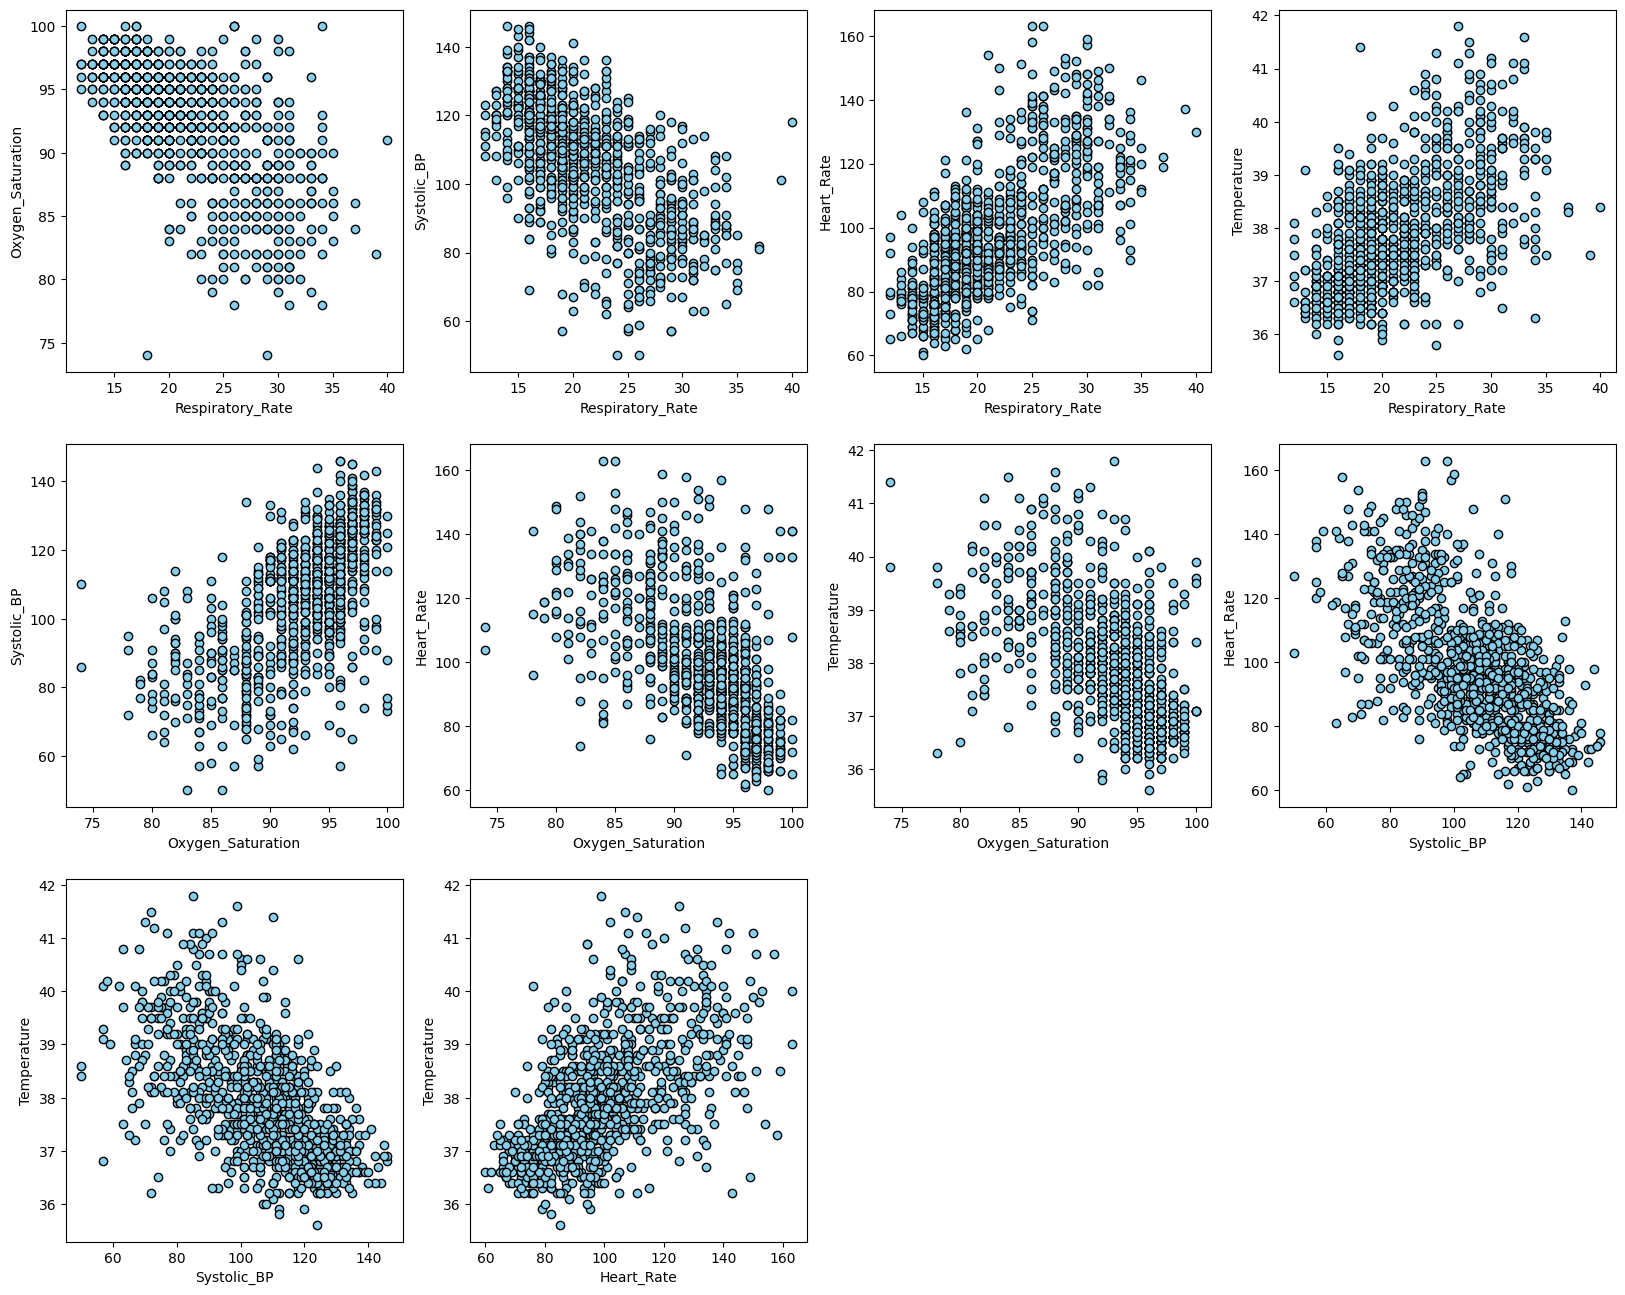

In [42]:
count = 0
plt.figure(figsize=(20, 16))
for i in range(0, len(columns_for_print) - 1):
    for j in range(i + 1, len(columns_for_print)):
        count += 1
        first = columns_for_print[i]
        second = columns_for_print[j]
        plt.subplot(3, 4, count)
        plt.scatter(ds[first], ds[second], color='skyblue', edgecolor='black')
        plt.xlabel(first)
        plt.ylabel(second)

In [43]:
for i in range(0, len(columns_for_print) - 1):
    for j in range(i + 1, len(columns_for_print)):
        first = columns_for_print[i]
        second = columns_for_print[j]
        data_1 = ds[first]
        data_2 = ds[second]
        print(first, second, stats.pearsonr(data_1, data_2))

Respiratory_Rate Oxygen_Saturation PearsonRResult(statistic=np.float64(-0.6314031677415982), pvalue=np.float64(2.391352655286793e-112))
Respiratory_Rate Systolic_BP PearsonRResult(statistic=np.float64(-0.6208415678829583), pvalue=np.float64(1.2608882133619198e-107))
Respiratory_Rate Heart_Rate PearsonRResult(statistic=np.float64(0.6764097149856216), pvalue=np.float64(1.059226549576258e-134))
Respiratory_Rate Temperature PearsonRResult(statistic=np.float64(0.5796337557106652), pvalue=np.float64(8.094576060042334e-91))
Oxygen_Saturation Systolic_BP PearsonRResult(statistic=np.float64(0.6007745095661917), pvalue=np.float64(3.903480770308219e-99))
Oxygen_Saturation Heart_Rate PearsonRResult(statistic=np.float64(-0.5876779827558762), pvalue=np.float64(6.543082144882173e-94))
Oxygen_Saturation Temperature PearsonRResult(statistic=np.float64(-0.565202699067047), pvalue=np.float64(1.7579147941501738e-85))
Systolic_BP Heart_Rate PearsonRResult(statistic=np.float64(-0.6497329356816157), pvalue=n

Искусственный пример

PearsonRResult(statistic=np.float64(0.99998828625046), pvalue=np.float64(0.0))

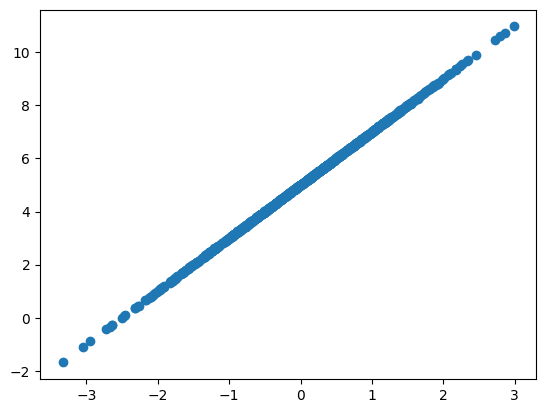

In [44]:
x = np.random.normal(0, 1, 1000)
y = 2 * x + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.pearsonr(x, y)

PearsonRResult(statistic=np.float64(0.03623756379213288), pvalue=np.float64(0.25226087043993195))

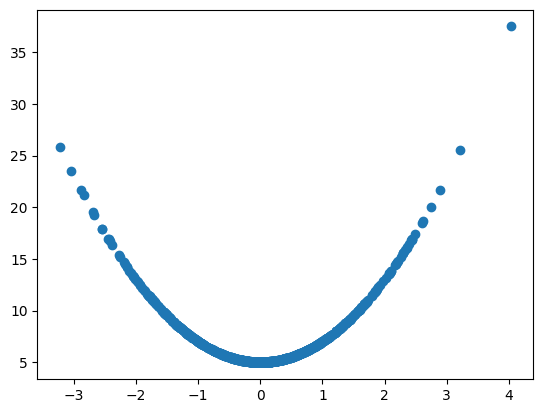

In [45]:
x = np.random.normal(0, 1, 1000)
y = 2 * x ** 2 + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.pearsonr(x, y)

### 2. Коэффициент корреляции Спирмена

Коэффициент корреляции Спирмена определяет монотонную корреляцию между данными.

Данные должны быть непрерывными и независимыми, имеется предположение о монотонности данных, не так чувствителен к выбросам 

In [46]:
for i in range(0, len(columns_for_print) - 1):
    for j in range(i + 1, len(columns_for_print)):
        first = columns_for_print[i]
        second = columns_for_print[j]
        data_1 = ds[first]
        data_2 = ds[second]
        print(first, second, stats.spearmanr(data_1, data_2))

Respiratory_Rate Oxygen_Saturation SignificanceResult(statistic=np.float64(-0.6281503521634361), pvalue=np.float64(7.118978370344049e-111))
Respiratory_Rate Systolic_BP SignificanceResult(statistic=np.float64(-0.6334449984013699), pvalue=np.float64(2.7829177396786904e-113))
Respiratory_Rate Heart_Rate SignificanceResult(statistic=np.float64(0.6799812369276206), pvalue=np.float64(1.198732962139928e-136))
Respiratory_Rate Temperature SignificanceResult(statistic=np.float64(0.5914428072681334), pvalue=np.float64(2.1799877035655025e-95))
Oxygen_Saturation Systolic_BP SignificanceResult(statistic=np.float64(0.6049464511901671), pvalue=np.float64(7.51519894195824e-101))
Oxygen_Saturation Heart_Rate SignificanceResult(statistic=np.float64(-0.6289604082728808), pvalue=np.float64(3.0693192370354748e-111))
Oxygen_Saturation Temperature SignificanceResult(statistic=np.float64(-0.611951131893323), pvalue=np.float64(8.664326486022808e-104))
Systolic_BP Heart_Rate SignificanceResult(statistic=np.flo

Искусственный пример

SignificanceResult(statistic=np.float64(0.9999796119796122), pvalue=np.float64(0.0))

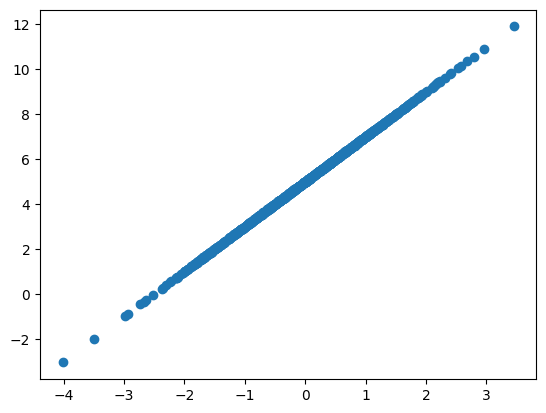

In [47]:
x = np.random.normal(0, 1, 1000)
y = 2 * x + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.001395685395685396), pvalue=np.float64(0.9648404214466804))

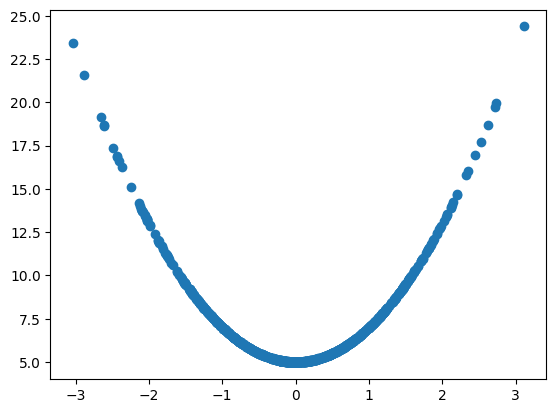

In [48]:
x = np.random.normal(0, 1, 1000)
y = 2 * x ** 2 + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.spearmanr(x, y)

### 3. Коэффициент корреляции Кендалла

Коэффициент корреляции Кендалла определяет монотонную корреляцию между данными.

Требует непрерывные, независимые данные

In [49]:
for i in range(0, len(columns_for_print) - 1):
    for j in range(i + 1, len(columns_for_print)):
        first = columns_for_print[i]
        second = columns_for_print[j]
        data_1 = ds[first]
        data_2 = ds[second]
        print(first, second, stats.kendalltau(data_1, data_2))

Respiratory_Rate Oxygen_Saturation SignificanceResult(statistic=np.float64(-0.47875106089700387), pvalue=np.float64(2.2421945495324416e-100))
Respiratory_Rate Systolic_BP SignificanceResult(statistic=np.float64(-0.45964337450422965), pvalue=np.float64(6.251670405455038e-98))
Respiratory_Rate Heart_Rate SignificanceResult(statistic=np.float64(0.5013233644758537), pvalue=np.float64(3.452905425774921e-116))
Respiratory_Rate Temperature SignificanceResult(statistic=np.float64(0.43394571136828014), pvalue=np.float64(1.2900274210547641e-86))
Oxygen_Saturation Systolic_BP SignificanceResult(statistic=np.float64(0.4518705711737615), pvalue=np.float64(3.499242101091526e-93))
Oxygen_Saturation Heart_Rate SignificanceResult(statistic=np.float64(-0.4753545216247186), pvalue=np.float64(5.730297660073154e-103))
Oxygen_Saturation Temperature SignificanceResult(statistic=np.float64(-0.4561265110279967), pvalue=np.float64(5.915295341661598e-94))
Systolic_BP Heart_Rate SignificanceResult(statistic=np.fl

Искусственный пример

SignificanceResult(statistic=np.float64(0.9965765765765766), pvalue=np.float64(0.0))

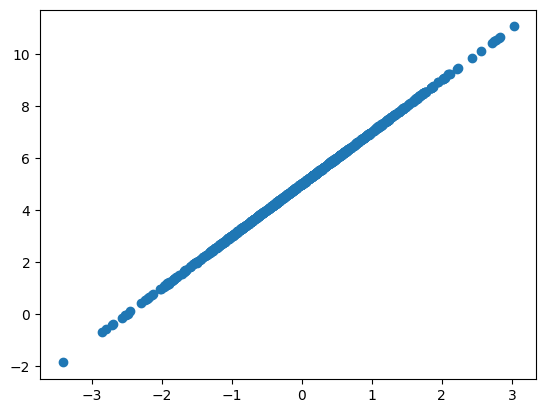

In [50]:
x = np.random.normal(0, 1, 1000)
y = 2 * x + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.kendalltau(x, y)

SignificanceResult(statistic=np.float64(0.0023503503503503505), pvalue=np.float64(0.911384703608511))

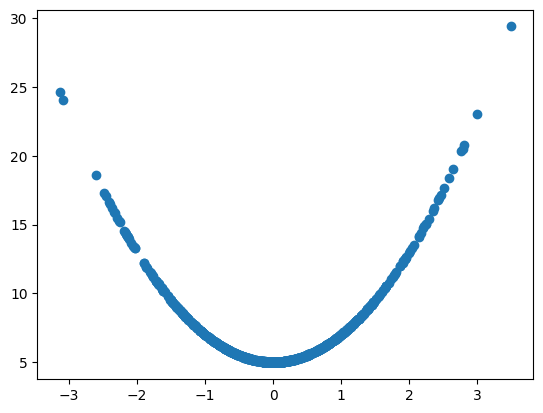

In [51]:
x = np.random.normal(0, 1, 1000)
y = 2 * x ** 2 + 5 + np.random.normal(0, 1, 1000) * 0.01
plt.scatter(x, y)
stats.kendalltau(x, y)

# 3. Продемонстрировать использование методов хи-квадрат, точного теста Фишера, теста МакНемара, Кохрана-Мантеля-Хензеля.

### 1. Метод $\chi ^2$

$\chi ^2$ подсчитывает частоты попаданий значений в категорию, поэтому для его применения нужны либо категориальные данные, либо группировка в непрерывных. В каждой группе минимум 5 значений. И требуем независимость наблюдений

p-value маленькое - данные говорят о зависимости переменных

In [52]:
data_1 = ds['O2_Scale']
data_2 = ds['On_Oxygen']
print(stats.chi2_contingency(pd.crosstab(data_1, data_2)))

Chi2ContingencyResult(statistic=np.float64(61.73674006751403), pvalue=np.float64(3.9258637886079314e-15), dof=1, expected_freq=array([[635.976, 240.024],
       [ 90.024,  33.976]]))


In [53]:
pd.crosstab(data_1, data_2)

On_Oxygen,0,1
O2_Scale,,
1,673,203
2,53,71


### 2. Точный тест Фишера

Предпочтительно использование в случаях, когда матрица имеет размер 2x2. 

In [54]:
for i in ds.columns:
    print(len(ds[i].unique()), i)

1000 Patient_ID
27 Respiratory_Rate
24 Oxygen_Saturation
2 O2_Scale
89 Systolic_BP
99 Heart_Rate
61 Temperature
5 Consciousness
2 On_Oxygen
4 Risk_Level


In [55]:
data_1 = ds['O2_Scale']
data_2 = ds['On_Oxygen']
print(stats.fisher_exact(pd.crosstab(data_1, data_2)))

SignificanceResult(statistic=np.float64(4.4412120085509805), pvalue=np.float64(5.943086083342583e-14))


### 3. Тест МакНемара

Применяется для парных данных, например, данные о пациенте до применения препарата и после. Тест позволяет понять, изменились ли результаты

В нашем датасете нет реальных парных данных, поэтому создадим искусственно

In [56]:
before = np.random.choice([0, 1], 1000, p=[0.7, 0.3])
after_1 = np.random.choice([0, 1], 1000, p=[0.6, 0.4])

In [57]:
pd.crosstab(before, after_1)

col_0,0,1
row_0,,
0,443,259
1,184,114


In [58]:
from statsmodels.stats.contingency_tables import mcnemar

print(mcnemar(pd.crosstab(before, after_1)))

pvalue      0.00042598927457656005
statistic   184.0


### 4. Тест Кохрана-Мантеля-Хензеля

Тест Кохрана-Мантеля-Хензеля проводится засчет разделения данных третьей переменной аналогично прошлому тесту

In [59]:
from statsmodels.stats.contingency_tables import StratifiedTable

data = []
for i in sorted(ds['Consciousness'].unique()):
    tmp = ds[ds['Consciousness'] == i]
    data.append(pd.crosstab(tmp['On_Oxygen'], tmp['O2_Scale']).values)
    print(i)
    print(pd.crosstab(tmp['On_Oxygen'], tmp['O2_Scale']))
print(StratifiedTable(data).test_null_odds())

A
O2_Scale     1   2
On_Oxygen         
0          643  51
1          165  55
C
O2_Scale   1  2
On_Oxygen      
0          2  0
1          3  2
P
O2_Scale    1  2
On_Oxygen       
0           4  0
1          11  5
U
O2_Scale    1  2
On_Oxygen       
0          11  1
1          10  4
V
O2_Scale    1  2
On_Oxygen       
0          13  1
1          14  5
pvalue      5.984102102729594e-14
statistic   56.37646553348522


Код проверяет, есть ли связь между O2_Scale и On_Oxygen после учета Consciousness. По тесту можем сказать, что есть

# 4. Проверить наличие мультиколлинеарности в данных с помощью корреляционной матрицы и фактора инфляции дисперсии.

### 1. Корреляционная матрица

В построении корреляционной матрицы участвуют только численные параметры, поэтому можно категориальные преобразовать. Используется коэффициент корреляции Пирсона

In [60]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


<Axes: >

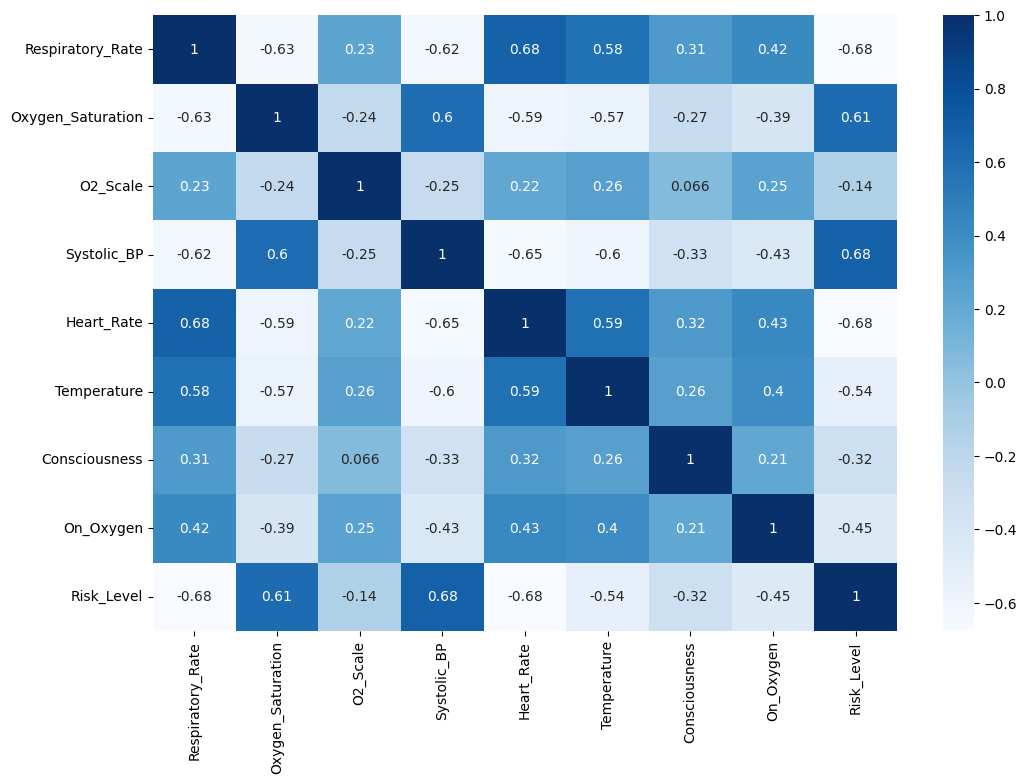

In [61]:
from sklearn.preprocessing import LabelEncoder

ds_to_cor = ds.drop('Patient_ID', axis=1)
cols_to_encode = ['Consciousness', 'Risk_Level']
le = LabelEncoder()

for col in cols_to_encode:
    ds_to_cor.loc[:, col] = le.fit_transform(ds_to_cor[col])
plt.figure(figsize=(12,8))
sns.heatmap(ds_to_cor.corr(), annot=True, cmap=plt.cm.Blues)

### 2. Фактор инфляции дисперсии

Нужен для диагностики мультиколлинеарности. Он помогает понять, насколько сильно корреляция между независимыми переменными влияет на ошибку коэффициентов регрессии

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

ds_to_vif = ds.drop('Patient_ID', axis=1)
cols_to_encode = ['Consciousness', 'Risk_Level']
le = LabelEncoder()

for col in cols_to_encode:
    ds_to_vif.loc[:, col] = le.fit_transform(ds_to_vif[col])

ds_to_vif = ds_to_vif.apply(pd.to_numeric)

X = add_constant(ds_to_vif)  
ds_to_vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
ds_to_vif

const                3828.171598
Respiratory_Rate        2.515955
Oxygen_Saturation       2.079750
O2_Scale                1.143735
Systolic_BP             2.469161
Heart_Rate              2.497943
Temperature             1.931664
Consciousness           1.162644
On_Oxygen               1.386430
Risk_Level              2.679308
dtype: float64

Мультиколлинеарность отсутствует

# 5. Исследовать зависимости в данных с помощью дисперсионного анализа.

### Однофакторный дисперсионный анализ

Дисперсионный анализ применяется для сравнения средних значений переменной в разных группах. Для применения должно быть нормальное распределение

In [63]:
group1 = np.random.normal(0, 1, 100)
group2 = np.random.normal(5, 1, 100)
group3 = np.random.normal(10, 1, 100)

data = pd.DataFrame({
    'value': np.concatenate([group1, group2, group3]),
    'group': np.repeat(['A', 'B', 'C'], 100)
})

s, p = stats.f_oneway(
    data[data['group'] == 'A']['value'],
    data[data['group'] == 'B']['value'],
    data[data['group'] == 'C']['value']
)
print(s, p)

2292.051841099946 2.8800819581923954e-181


 ### Двухфакторный дисперсионный анализ

In [ ]:
from statsmodels.formula.api import ols

model1 = ols('Respiratory_Rate ~ C(On_Oxygen) + C(Consciousness) + C(On_Oxygen):C(Consciousness)', data=ds).fit()
anova_table1 = sm.stats.anova_lm(model1, typ=2)
print(anova_table1)

                                     sum_sq     df           F        PR(>F)
C(On_Oxygen)                    3455.842518    1.0  161.174189  2.528666e-34
C(Consciousness)                1540.279339    4.0   17.958954  3.010859e-14
C(On_Oxygen):C(Consciousness)    245.434554    4.0    2.861655  2.249027e-02
Residual                       21227.245539  990.0         NaN           NaN


# 6. Подогнать регрессионные модели (в том числе, нелинейные) к данным, а также оценить качество подобной аппроксимации.

### Логистическая регрессия

Воспользуемся логистической регрессией для предсказания Risk_Level. Для оценки модели будем использовать accuracy_score

In [65]:
ds = pd.read_csv('Health_Risk_Dataset.csv')
ds = ds.drop('Patient_ID', axis=1)

In [66]:
ds_to_reg = ds.copy()
le = LabelEncoder()
for i in ds_to_reg.columns:
    if ds_to_reg[i].dtype == 'object':
        ds_to_reg[i] = le.fit_transform(ds_to_reg[i])

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

X = ds_to_reg.drop('Risk_Level', axis=1)
y = ds_to_reg['Risk_Level']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=0)

parameters = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'sag', 'saga'],
    'classifier__max_iter': [2000, 5000, 10000]
}

grid_search = GridSearchCV(pipeline, parameters, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_valid)
print(accuracy_score(y_valid, y_pred))
print('best model:', best_model)

0.976
best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=100, max_iter=2000, solver='sag'))])


### Линейная регрессия

In [68]:
ds = pd.read_csv('Health_Risk_Dataset.csv')
ds = ds.drop('Patient_ID', axis=1)

ds_to_reg = ds.copy()
le = LabelEncoder()
for i in ds_to_reg.columns:
    if ds_to_reg[i].dtype == 'object':
        ds_to_reg[i] = le.fit_transform(ds_to_reg[i])

In [81]:
from sklearn.linear_model import RidgeClassifier

X = ds_to_reg.drop('Risk_Level', axis=1)
y = ds_to_reg['Risk_Level']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=0)

pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RidgeClassifier())
])

parameters_ridge = {
    'classifier__alpha': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['auto', 'svd', 'cholesky',   'lsqr', 'sparse_cg', 'sag', 'saga']
}   

grid_search_ridge = GridSearchCV(pipeline_ridge, parameters_ridge, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_valid)
print("Accuracy:", accuracy_score(y_valid, y_pred_ridge))
print("Best model:", best_ridge)

Accuracy: 0.736
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RidgeClassifier(alpha=100))])


### SVM

In [75]:
ds = pd.read_csv('Health_Risk_Dataset.csv')
ds = ds.drop('Patient_ID', axis=1)

ds_to_reg = ds.copy()
le = LabelEncoder()
for i in ds_to_reg.columns:
    if ds_to_reg[i].dtype == 'object':
        ds_to_reg[i] = le.fit_transform(ds_to_reg[i])

In [ ]:
from sklearn.svm import SVC

X = ds_to_reg.drop('Risk_Level', axis=1)
y = ds_to_reg['Risk_Level']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=0)

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(random_state=0))
])

parameters_svm = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'classifier__class_weight': [None, 'balanced']
}

grid_search_svm = GridSearchCV(pipeline_svm, parameters_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train, y_train)

best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_valid)
print("Accuracy:", accuracy_score(y_valid, y_pred_svm))
print("Best model:", best_svm)

Fitting 3 folds for each of 150 candidates, totalling 450 fits
Accuracy: 0.968
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=100, gamma=0.1, random_state=0))])
